In [1]:
%load_ext autoreload
%autoreload 3

In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina' # high res plotting

import sys
sys.path.append('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/spikeparam')
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/spe-1/spe1_helper_modules/'))
sys.path.append(('/Users/blancamartin/Desktop/Voytek_Lab/spike_waveform/spikeparam/AP_empirical_paper1/datasets/shared_helper_modules'))

# General imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import warnings
import pickle

warnings.filterwarnings(
    "ignore",
    message="use_inf_as_na option is deprecated",
    category=FutureWarning,
    module="seaborn")

warnings.filterwarnings(
    "ignore",
    message=r"invalid value encountered in log10",
    category=RuntimeWarning,
    module=r".*specparam.*",
)


# NeuroDSP and FOOOF modules
from neurodsp import spectral

from specparam import Bands


# Custom modules

from spk_feat_cluster_analysis import *

from spe1_plotting import *
from spikeparam.patch.fit import Spike

from config import NPX_CHANNELS, CELL_IDS, DICT_PATCH_FS, DICT_CHAN_PRED, DICT_SPK_THRESH, FILTER_SETTINGS, SPE1_DATA_ROOT, SPE1_PICKLE_ROOT


In [3]:
cell_num = 29 #MODIFY THIS WHEN RUNNING DIFFERENT CELLS 

npx_fs = 30000 # sampling rate
lfp_fs = 3500 # sampling rate

patch_fs = DICT_PATCH_FS[cell_num ]
spk_thresh = DICT_SPK_THRESH[cell_num]

npx_channels = NPX_CHANNELS
npx_patch_channel = DICT_CHAN_PRED[cell_num ]



In [4]:
# Parameters
FORCE_CLUSTER = False


### Loading spe-1 data:

I moved the data loading steps to a separate Jupyter Notebook (spe-1_load_data)




## Cell   
### Analyze Gamma LFP and whole patch clamp AP relationship for cell 

## Step 0: Get loaded data 

In [5]:
lfp_dir = os.path.join(SPE1_DATA_ROOT, 'filt_lfp_recordings', f'c{cell_num}_lfp.npy')
patch_dir = os.path.join(SPE1_DATA_ROOT, 'filt_patch_recordings', f'c{cell_num}_patch.npy')


In [6]:
#get LFP data
lfp_filt = np.load(lfp_dir)
lfp_one_ms = float(lfp_fs / 1000)
lfp_times = np.arange(0, np.shape(lfp_filt)[0]) / lfp_one_ms # in ms instead of sec

#get patch data 
patch_filt = np.load(patch_dir)
patch_one_ms = float(patch_fs  / 1000)
patch_times = np.arange(0, np.shape(patch_filt )[0]) / patch_one_ms # in ms instead of sec

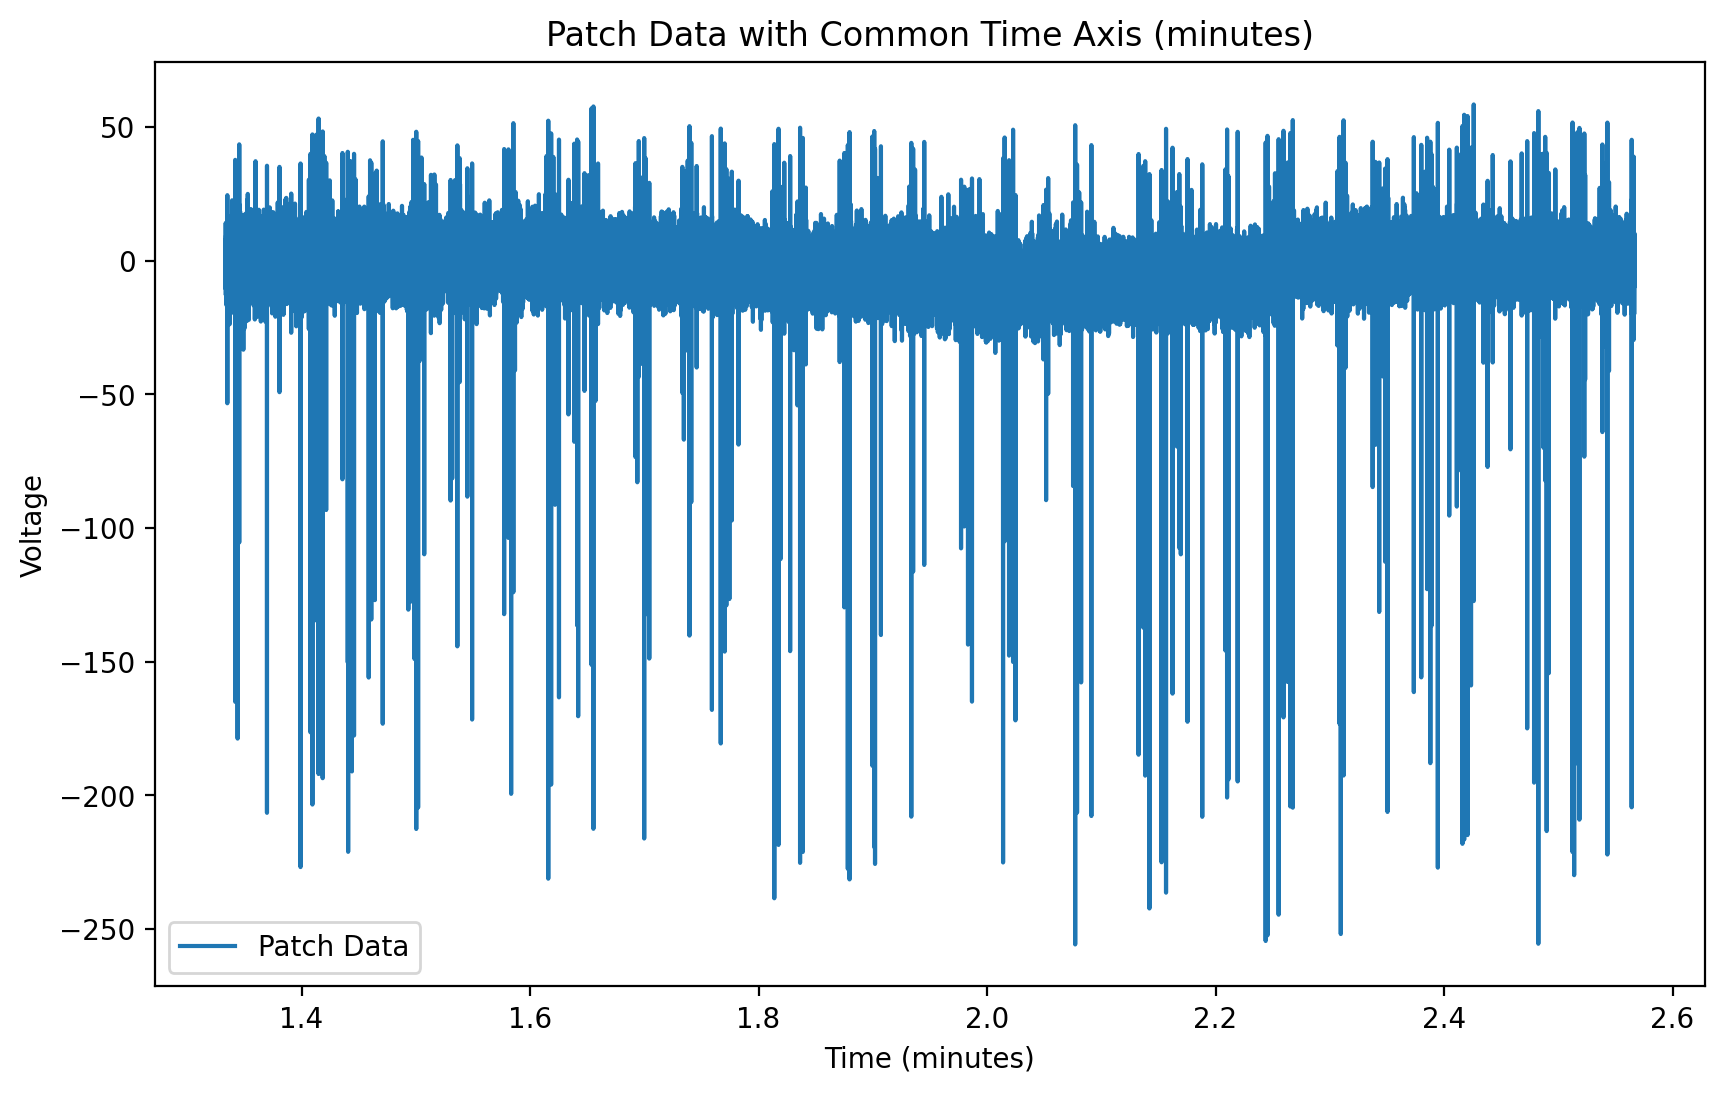

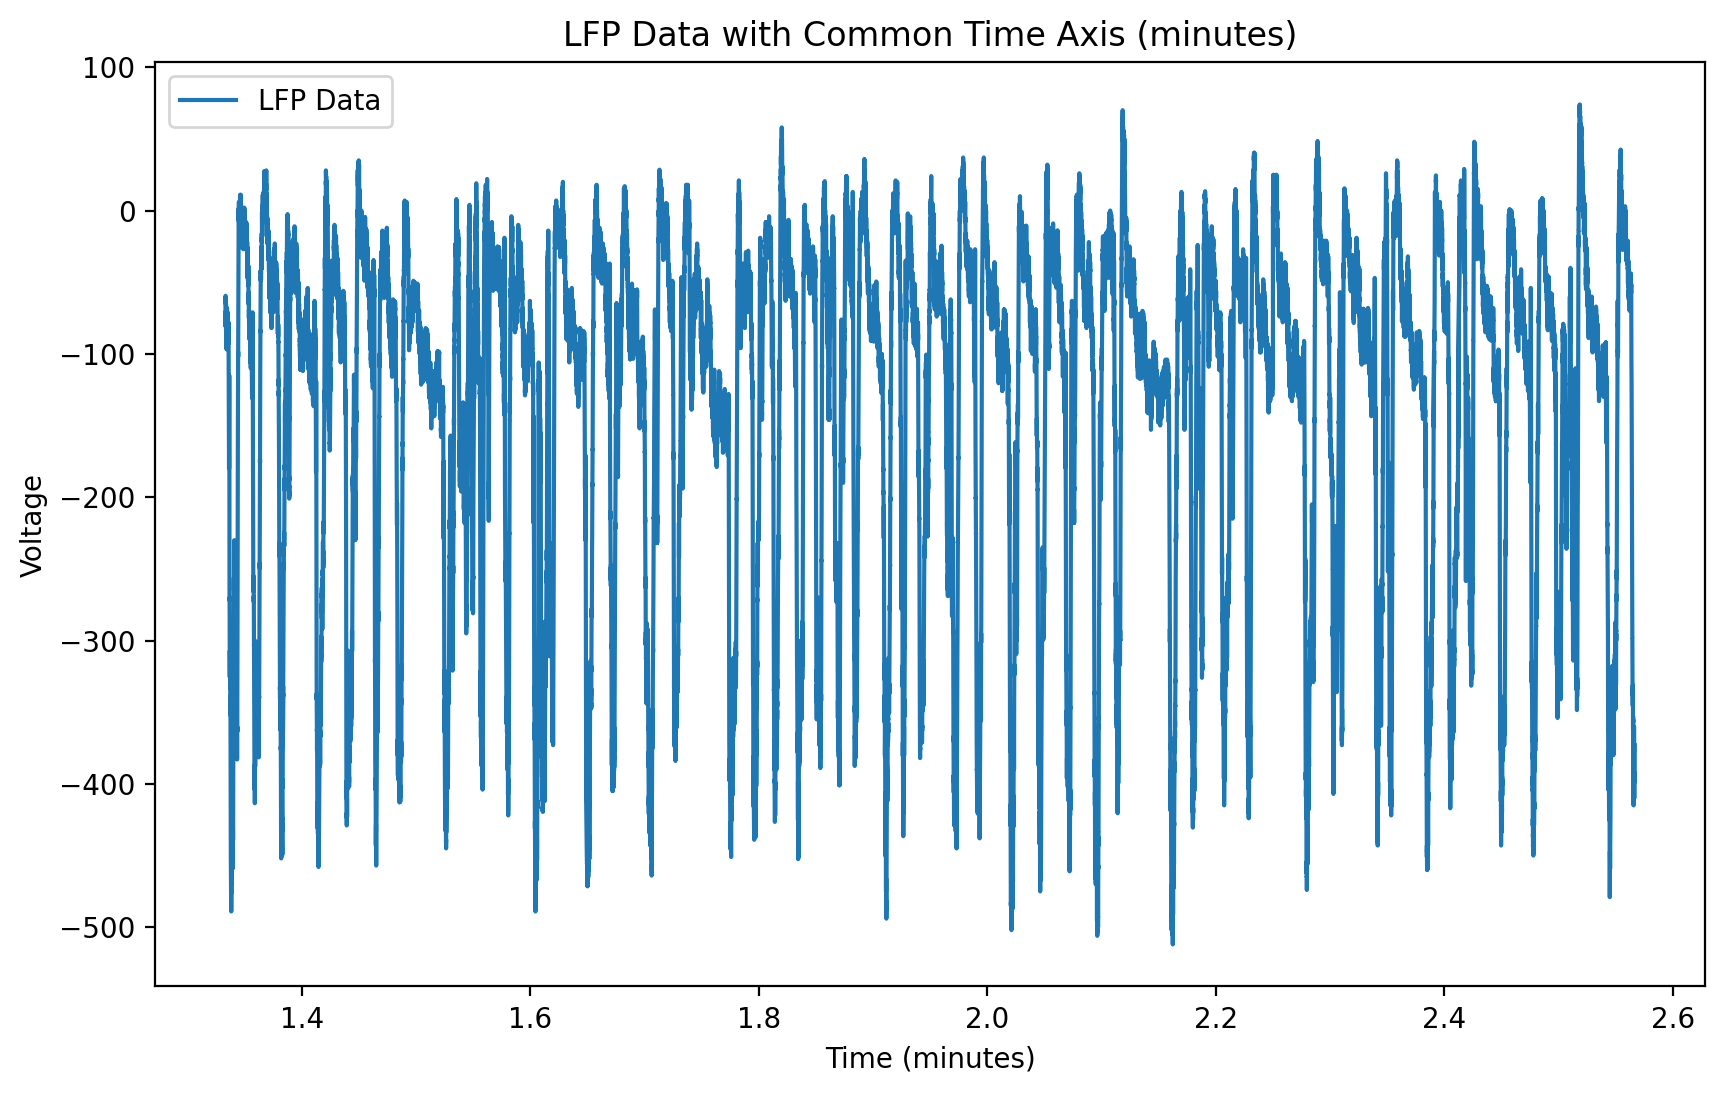

In [7]:
# Plot simultaneous patch and LFP data
# Convert time arrays to minutes
patch_times_min = patch_times / 60000  # Convert milliseconds to minutes
lfp_times_min = lfp_times / 60000  # Convert milliseconds to minutes

# Set the common time axis in minutes (e.g., from 13.3333 to 35.6667 minutes)
common_time_range_min = np.arange(80000 / 60000, 154000 / 60000, 1 / 60000)  # Adjust as needed

# Interpolate patch data onto the common time axis
patch_interp = np.interp(common_time_range_min, patch_times_min, patch_filt)

# Interpolate LFP data onto the common time axis
lfp_interp = np.interp(common_time_range_min, lfp_times_min, lfp_filt)

# Plot patch data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, patch_interp, label='Patch Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('Patch Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

# Plot LFP data with common time axis in minutes
plt.figure(figsize=(10, 6))
plt.plot(common_time_range_min, lfp_interp, label='LFP Data')
plt.xlabel('Time (minutes)')
plt.ylabel('Voltage')
plt.title('LFP Data with Common Time Axis (minutes)')
plt.legend()
plt.show()

## STEP 1: Detect and fit spikes from patch data

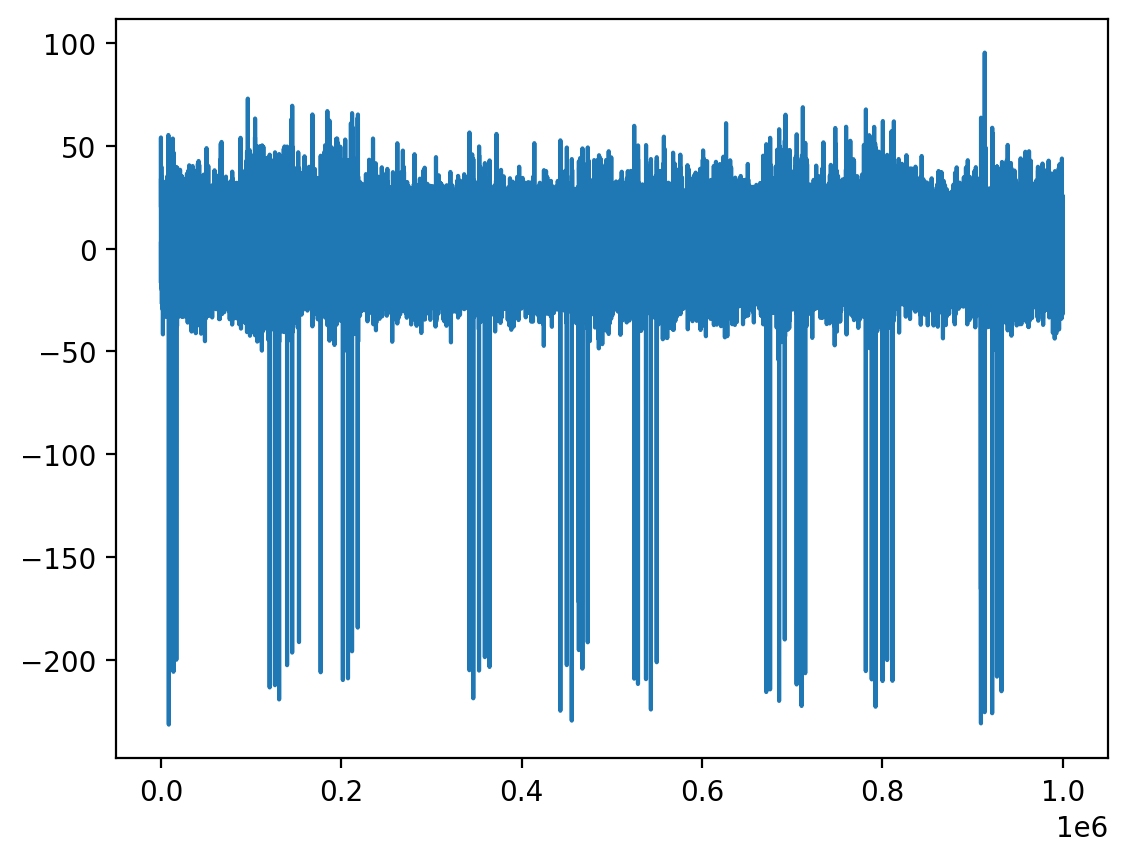

In [8]:
plt.plot(patch_filt[:1000000] )

In [9]:



#threshold in mVs
sp = Spike(thresh_amp=spk_thresh, window_length=(5., 5.), smooth_frac=.01)

In [10]:
#CHANGE FOR EACH CELL
sp.fit(patch_filt, patch_fs, n_jobs=-1, progress=tqdm, flip_signal=True)

Spike:   0%|          | 0/1137 [00:00<?, ?it/s]

Spike:   0%|          | 1/1137 [00:06<1:58:47,  6.27s/it]

Spike:   0%|          | 2/1137 [00:06<51:07,  2.70s/it]  

Spike:   1%|          | 8/1137 [00:06<08:55,  2.11it/s]

Spike:   3%|▎         | 34/1137 [00:06<01:29, 12.38it/s]

...

Spike:  94%|█████████▍| 1072/1137 [00:13<00:00, 189.19it/s]

Spike:  96%|█████████▌| 1094/1137 [00:13<00:00, 191.23it/s]

Spike:  98%|█████████▊| 1115/1137 [00:13<00:00, 192.75it/s]

Spike: 100%|██████████| 1137/1137 [00:13<00:00, 198.52it/s]

Spike: 100%|██████████| 1137/1137 [00:13<00:00, 82.73it/s] 

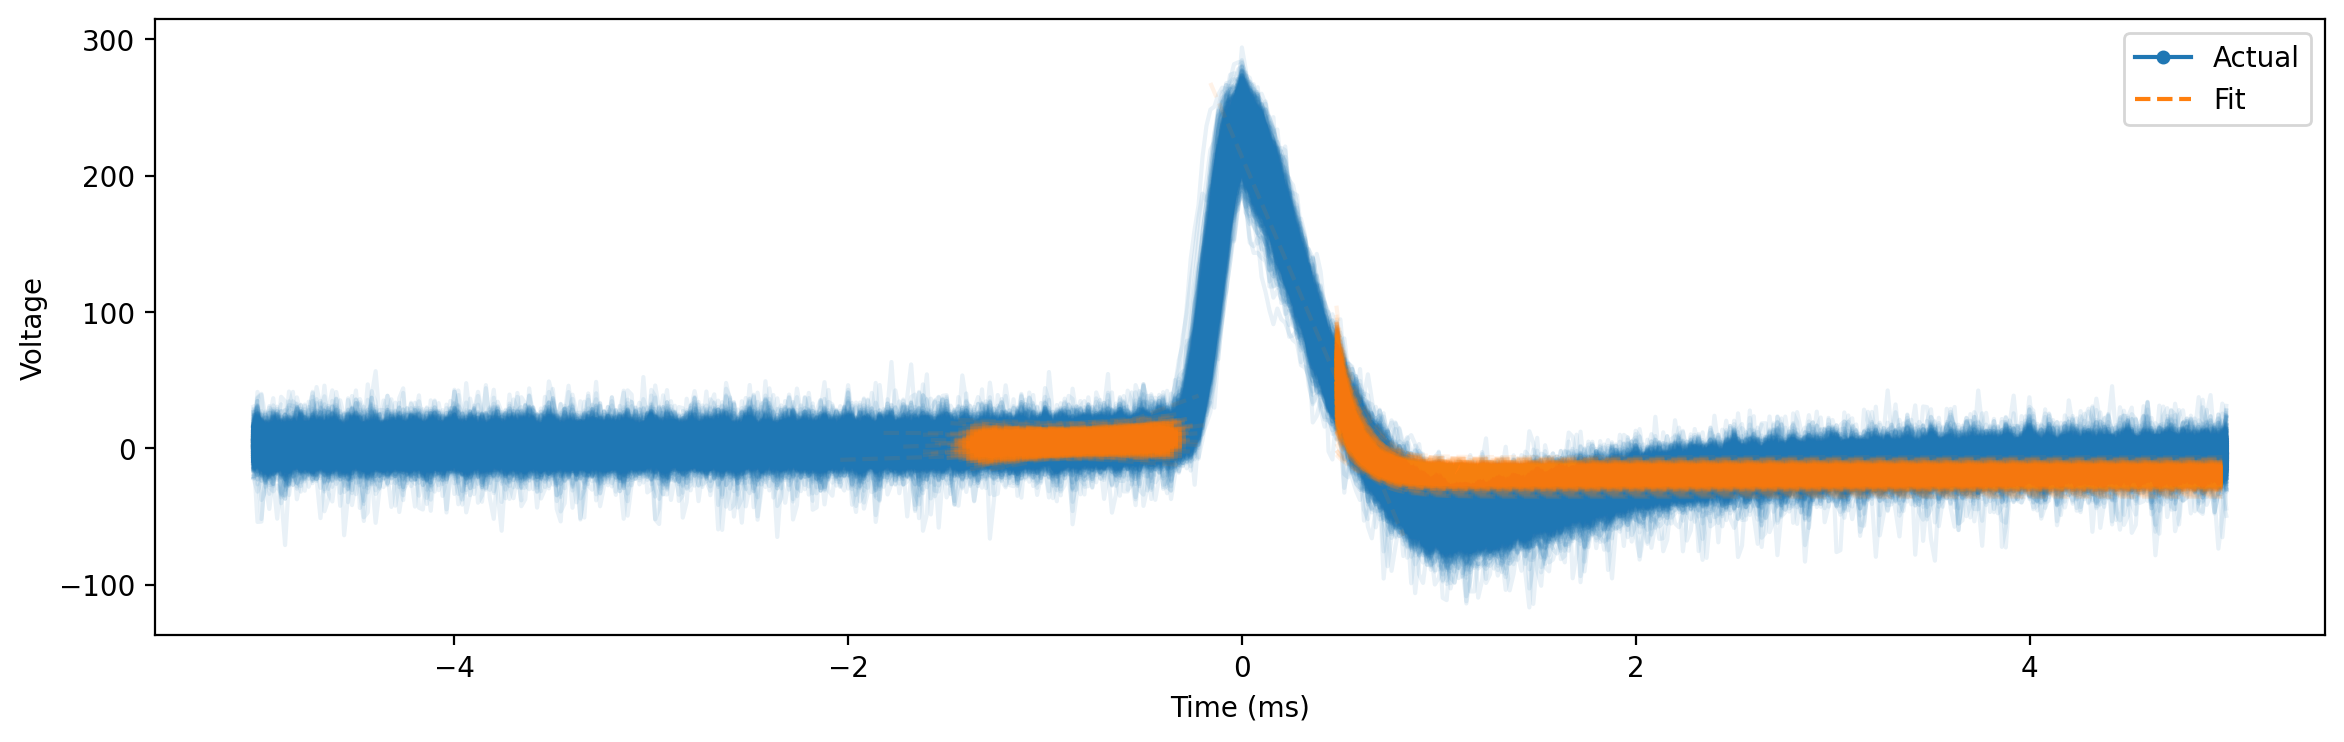

In [11]:
sp.plot()

### Filter spikes 

In [12]:
sp.filter_features()  # Applies default filters in-place

### Get spike dataframe (with spike times column)

In [13]:

df_features = sp.df_features

#add columns for spike times, both in idx and ms
df_features['spk_times_idx'] = sp.spike_inds
df_features['spk_times_ms'] = patch_times[sp.spike_inds]
df_features['spk_id'] = range(len(df_features))

In [14]:
df_features

,ramp_amp,inflection_time,inflection_amp,peak_amp,peak_width,peak_sharpness,exp_lambda,exp_const,log_isi,spk_times_idx,spk_times_ms,spk_id
0,16.862813,0.24,20.482062,226.382562,0.40,65.204808,8.901091,-12.200772,2.012967,8751,174.936358,0
1,12.634690,0.32,21.627337,204.553301,0.46,34.595527,7.551382,-18.438992,1.806515,13905,277.967096,1
2,6.226157,0.30,15.745633,195.801380,0.50,46.357331,6.914491,-14.853740,3.315691,17109,342.016472,2
3,-5.450283,0.36,15.181364,208.318495,0.44,33.806458,10.000000,-12.673519,2.070052,120592,2410.687383,3
4,3.522338,0.26,13.958932,211.711375,0.42,39.502673,8.451990,-14.414084,1.964806,126470,2528.191201,4
...,...,...,...,...,...,...,...,...,...,...,...,...
1132,0.985227,0.36,-5.210221,238.807541,0.46,34.039012,10.000000,-24.212752,2.142870,13477448,269420.142649,1126
1133,6.932325,0.34,14.075088,242.348137,0.44,45.887771,10.000000,-29.437076,2.115270,13484399,269559.096211,1127
1134,9.179865,0.34,11.784069,237.623929,0.48,32.044938,10.000000,-22.876796,2.233651,13490922,269689.493865,1128
1135,-7.942183,0.28,5.043331,236.820958,0.44,51.091099,10.000000,-27.195113,1.912440,13499489,269860.751981,1129


### Get spike times


In [15]:
spk_times_idx = df_features['spk_times_idx']
spk_times_ms = df_features['spk_times_ms']
spk_ids = df_features['spk_id']

In [16]:
df_features.columns

Index(['ramp_amp', 'inflection_time', 'inflection_amp', 'peak_amp',
       'peak_width', 'peak_sharpness', 'exp_lambda', 'exp_const', 'log_isi',
       'spk_times_idx', 'spk_times_ms', 'spk_id'],
      dtype='str')

## STEP 2: Cluster spike groups 

#### Plot distribution of all features

Plotting spike features...
Removing outliers using IQR method (multiplier=3)


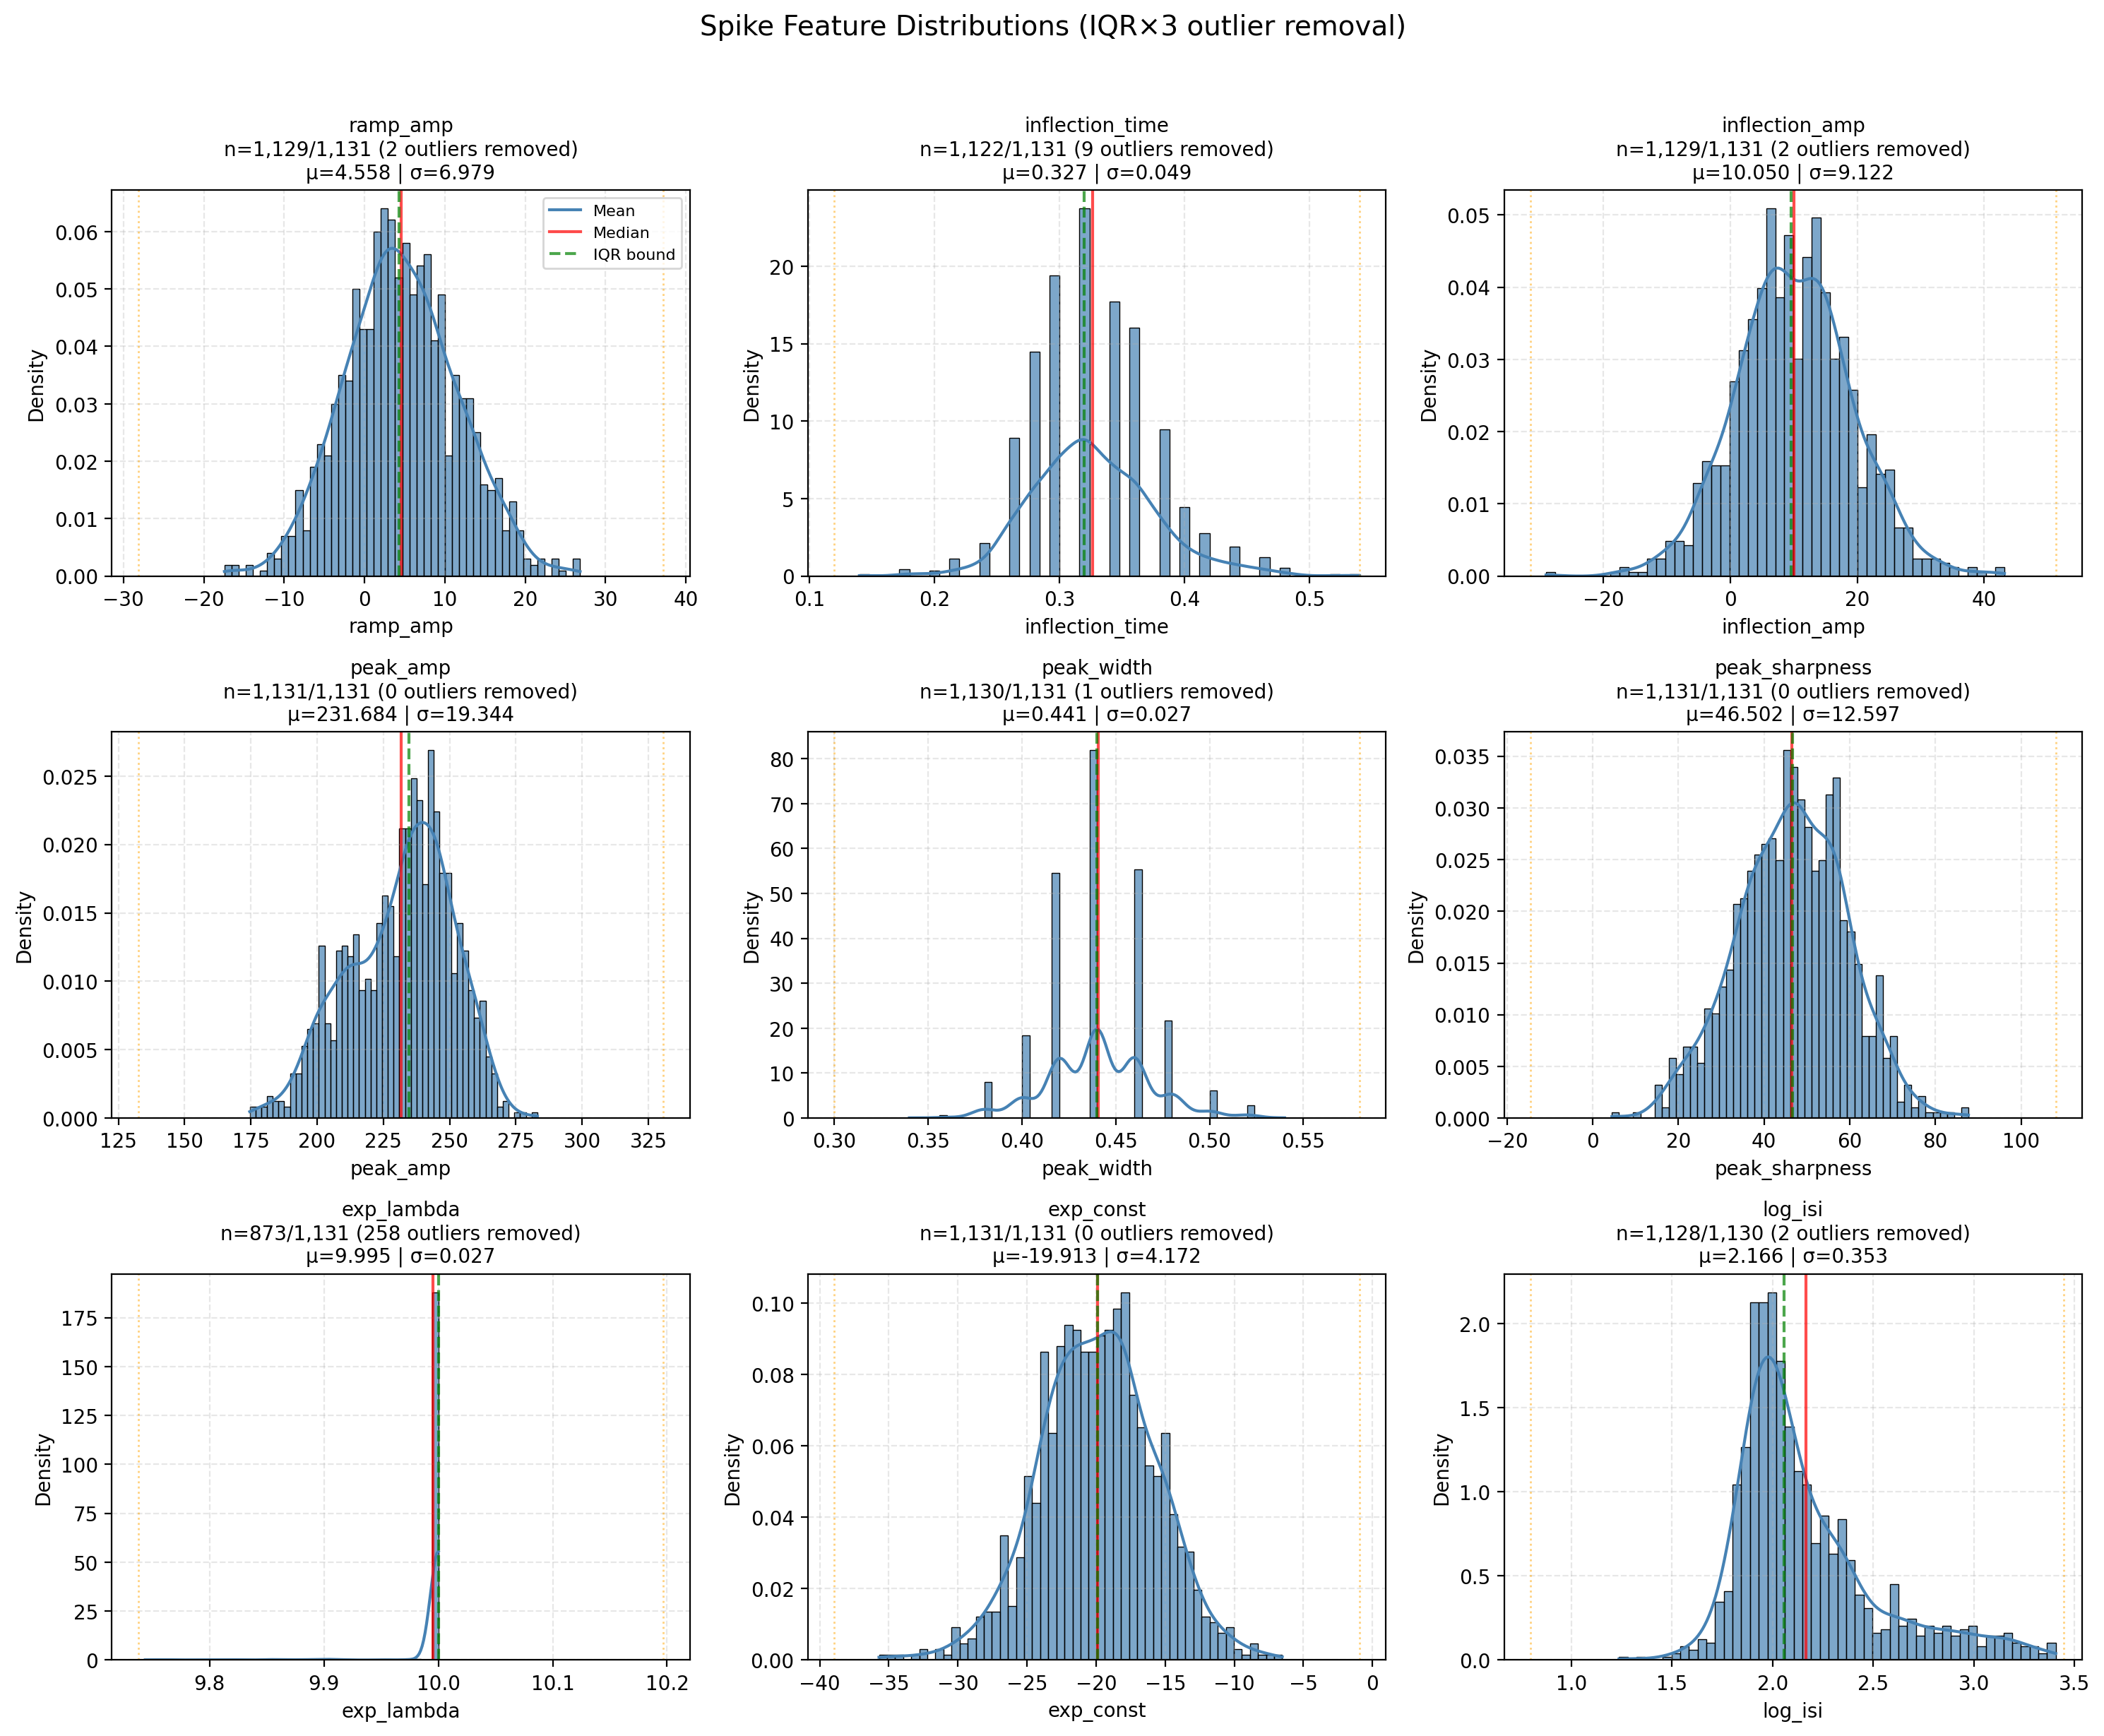


FEATURE DISTRIBUTION SUMMARY
Feature              Total N    Clean N    Outliers   % Removed  Mean       Std       
------------------------------------------------------------------------------------------
ramp_amp             1131       1129       2          0.2        4.558      6.979     
inflection_time      1131       1122       9          0.8        0.327      0.049     
inflection_amp       1131       1129       2          0.2        10.050     9.122     
peak_amp             1131       1131       0          0.0        231.684    19.344    
peak_width           1131       1130       1          0.1        0.441      0.027     
peak_sharpness       1131       1131       0          0.0        46.502     12.597    
exp_lambda           1131       873        258        22.8       9.995      0.027     
exp_const            1131       1131       0          0.0        -19.913    4.172     
log_isi              1130       1128       2          0.2        2.166      0.353     


In [17]:
plot_spike_feature_distributions(df_features)

### No clusters